In [2]:
!pip install pandas matplotlib seaborn scikit-learn

  Using cached pandas-3.0.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.5.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB

Matplotlib is building the font cache; this may take a moment.


--- Dataset Preview ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMov

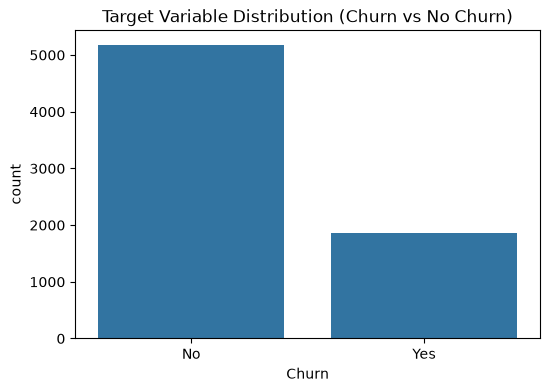

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 2. Look at the first 5 rows of data
print("--- Dataset Preview ---")
print(df.head())

# 3. See how bad the class imbalance is (How many people actually churned?)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn')
plt.title('Target Variable Distribution (Churn vs No Churn)')
plt.show()

In [6]:
# 1. Drop the CustomerID column (it's just a random ID, useless for patterns)
df = df.drop(columns=['customerID'])

# 2. FIX: Added the comma before errors='coerce'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 3. Convert our target 'Churn' from Yes/No into 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. See the remaining text columns we need to convert later
print("Columns that are still text/words:")
print(df.select_dtypes(include=['object']).columns.tolist())

Columns that are still text/words:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/var/folders/z1/72b8d06n17j05x4kwy3n6q_r0000gn/T/ipykernel_40431/1088077948.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include=['object']).columns.tolist())


In [7]:
# Convert all text columns into numeric columns using One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Let's see what our data looks like now
print("New columns after encoding:")
print(df_encoded.columns.tolist()[:10]) # Just printing the first 10 columns
print(f"\nTotal number of columns now: {len(df_encoded.columns)}")

New columns after encoding:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service']

Total number of columns now: 31


In [8]:
from sklearn.model_selection import train_test_split

# 1. Define X (everything except the Churn column)
X = df_encoded.drop(columns=['Churn'])

# 2. Define y (only the Churn column)
y = df_encoded['Churn']

# 3. Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (5634, 30)
Testing features shape: (1409, 30)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the model
# (We increase max_iter to give the math equations enough time to figure things out)
model = LogisticRegression(max_iter=1000)

# 2. Train the model (The AI studies the textbook)
model.fit(X_train, y_train)

# 3. Predict on the test data (The AI takes the final exam)
predictions = model.predict(X_test)

# 4. Check basic accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 82.04%


/Users/suravivijayjoshi/churn-project/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

# Print the real scorecard
print("--- Detailed Performance Report ---")
print(classification_report(y_test, predictions))

# Print the raw matrix of correct vs incorrect guesses
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, predictions))

--- Detailed Performance Report ---
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

--- Confusion Matrix ---
[[933 103]
 [150 223]]


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Feature Engineering: Create a ratio feature on our original dataframe
df_encoded['ChargeRatio'] = df_encoded['MonthlyCharges'] / (df_encoded['TotalCharges'] + 1) # +1 avoids division by zero

# Re-split the data with our new feature included
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Re-train with BALANCED class weights
balanced_model = LogisticRegression(class_weight='balanced', max_iter=1000)
balanced_model.fit(X_train, y_train)

# 3. Predict again
balanced_predictions = balanced_model.predict(X_test)

# 4. Check the new scorecard
print("--- NEW Balanced Performance Report ---")
print(classification_report(y_test, balanced_predictions))

print("--- NEW Confusion Matrix ---")
print(confusion_matrix(y_test, balanced_predictions))

--- NEW Balanced Performance Report ---
              precision    recall  f1-score   support

           0       0.93      0.73      0.81      1036
           1       0.53      0.84      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

--- NEW Confusion Matrix ---
[[754 282]
 [ 61 312]]


/Users/suravivijayjoshi/churn-project/ml_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/var/folders/z1/72b8d06n17j05x4kwy3n6q_r0000gn/T/ipykernel_40431/386252715.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='coolwarm')


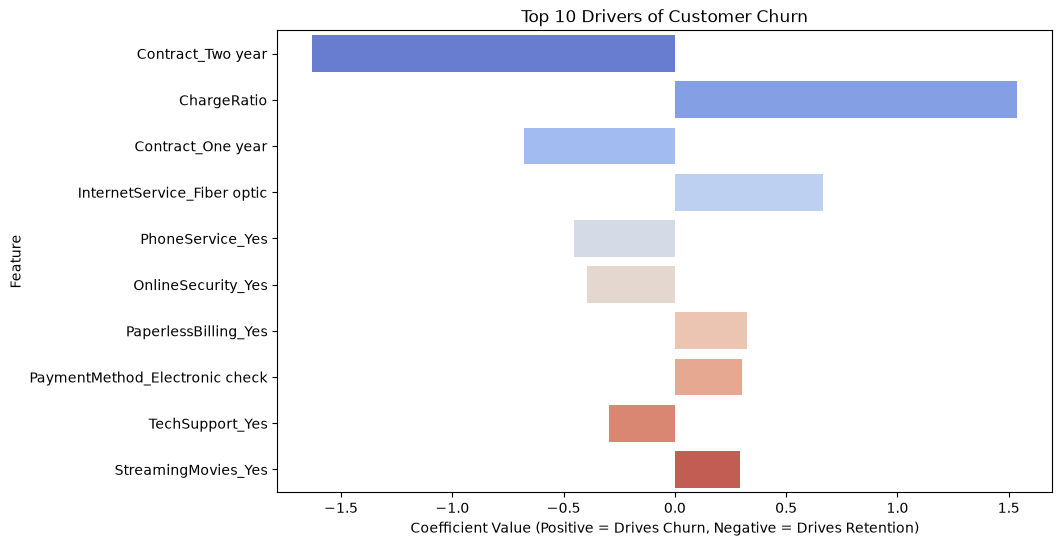

In [12]:
import numpy as np

# 1. Get the coefficients from the trained model
coefficients = balanced_model.coef_[0]

# 2. Match them up with the column names
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': coefficients
})

# 3. Sort them by absolute value to see the strongest drivers
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False).head(10)

# 4. Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='coolwarm')
plt.title('Top 10 Drivers of Customer Churn')
plt.xlabel('Coefficient Value (Positive = Drives Churn, Negative = Drives Retention)')
plt.show()